In [29]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=  df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/sachintamangyonjan/.cache/huggingface/datasets/lukebarousse___data_jobs/default/0.0.0/1d815e9ce232eb27db11939c44eb048fe6d2e9ab (last modified on Sun Sep 29 14:34:04 2024).


In [30]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

In [31]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [32]:
df_DA_US_explode = df_DA_US.explode('job_skills')

In [33]:
df_DA_US_pivot = df_DA_US_explode.pivot_table(index = 'job_posted_month_no',columns='job_skills',aggfunc = 'size', fill_value = 0)

df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending= False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')
df_DA_US_pivot



job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,google chat,openstack,theano,asp.net core,qt,couchdb,capacitor,codecommit,chainer,msaccess
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,0,0,0,0,0,0,1,1,0,0
2,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
3,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,1,0,0,0,0,0,0,0,0,0
4,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,1,0,0,0,0
5,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,0,0,0,0,1
6,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,1,0,0,1,0,0,0,0,0
7,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
8,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
9,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [34]:
DA_totals= df_DA_US.groupby('job_posted_month_no').size()

In [35]:
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis=0)


In [36]:
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')


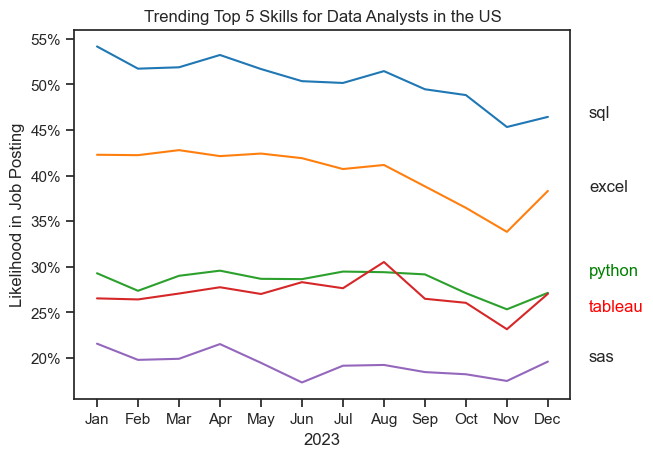

In [71]:
# df_plot = df_DA_US_percent.iloc[:, :5]
# sns.lineplot(data= df_plot, dashes= False, palette= 'tab10')
# sns.set_theme(style='ticks')

# plt.title('Trending Top 5 Skills for Data Analysts in the US')
# plt.xlabel('2023')
# plt.ylabel('Likelihood in Job Posting')
# plt.legend().remove()

# from matplotlib.ticker import PercentFormatter
# ax = plt.gca()
# ax.yaxis.set_major_formatter(PercentFormatter(decimals= 0))

# for i in range(5):
#    if df_plot.columns[i] == 'python':
#         # Adjust the position for python
#         plt.text(12, df_plot.iloc[-1, i] + 2, df_plot.columns[i], color='green')  # Moves the label upwards by 2 units
#     elif df_plot.columns[i] == 'tableau' :
#         # Adjust the position for tableau
#         plt.text(12, df_plot.iloc[-1, i] - 2, df_plot.columns[i], color='red')  # Moves the label downwards by 2 units
        
#     else:
#     plt.text(12,df_plot.iloc[-1,i], df_plot.columns[i])


# plt.show()

# Assuming df_DA_US_percent is already defined and processed
df_plot = df_DA_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')

# Set title and labels
plt.title('Trending Top 5 Skills for Data Analysts in the US')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Posting')

# Remove the legend
plt.legend().remove()

# Set y-axis as percentages
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Plot the labels for each skill
for i in range(5):
    if df_plot.columns[i] == 'python':
        # Adjust the position for python
        plt.text(12, df_plot.iloc[-1, i] + 2, df_plot.columns[i], color='green')  # Moves the label upwards by 2 units
    elif df_plot.columns[i] == 'tableau':
        # Adjust the position for tableau
        plt.text(12, df_plot.iloc[-1, i] - 2, df_plot.columns[i], color='red')  # Moves the label downwards by 2 units
    else:
        # Default label positions for other skills
        plt.text(12, df_plot.iloc[-1, i], df_plot.columns[i])

# Show the plot
plt.show()

